# Week 5 — calibrated discrete covariate HMMs on DTU CO2 data

**Scope.** One room, 30-minute aggregation, **discrete** models only: a Gaussian and an
autoregressive emission with a covariate-driven (`DynamicTransition`) transition, plus a
**second-order** covariate transition (`DynamicTransitionHigherOrder`) that asks whether the
chain's memory buys anything once the covariates are already in the transition.

**How to use this notebook.** Everything you would want to vary lives in the config cell
below: the number of states, AR lags, transition order, which weather channels enter the
transition, and how many daily / weekly Fourier cycles to use. Set them, run the notebook top
to bottom, read the diagnostics. Nothing further down needs editing.

**Data.** CO2 comes from the prepared arrays written by `drivers/clean_dtu_data.py` (run
`uv run python -m drivers.clean_dtu_data` once); the covariates are built *here*, from the
segment's timestamps and `data/raw/dtu/weather.csv`, via `drivers.utils.build_covariates`.
The driver's own `X_*.csv` are deliberately not read: they are frozen at a fixed harmonic
count, so honouring a config other than that one would mean unpicking them.

**Calibration** (applied by the driver). The NDIR sensors drift, so the floor of a room's CO2
series sits wherever the sensor's zero happens to be rather than at the ~400 ppm outdoor
background. The driver shifts the whole series by one constant so its minimum is exactly
400 ppm. A pure shift leaves every difference, gap and dynamic untouched — it only makes the
level comparable across rooms and physically interpretable.

**Splits.** The driver cuts the series chronologically into **train -> validation -> test**, but
this notebook loads only **train + validation**. Models are fitted on train and every held-out
number below is read off validation; the test block is never touched here. Covariates are
z-scored with *training* statistics only, so nothing downstream leaks into the scaling.

**Evaluation.** Rolling **6-hour-ahead** forecasts against a persistence baseline
(RMSE / MAPE / R2) on the validation block, residual diagnostics, and in-sample
LL / AIC / BIC.

In [11]:
import jax
jax.config.update("jax_enable_x64", True)   # must come before anything touches JAX

# ===================== CONFIG — the only cell you need to edit =====================

ROOM_SLUG, TAG  = "room_012", "30min"   # which prepared dataset to read

# --- Covariates entering the transition -------------------------------------------
USE_OFF_DAY     = True     # weekend / Danish public holiday flag
WEATHER         = [
        "mean_temp"
        ]
#   available: mean_temp, mean_relative_hum, mean_wind_speed,
#              mean_pressure, mean_cloud_cover, mean_radiation

# --- Calendar cycles (0 drops the block entirely) ---------------------------------
N_DAILY_CYCLES  = [1, 4]     # -> sin_tod_1..k  / cos_tod_1..k
N_WEEKLY_CYCLES = [1, 7]     # -> sin_week_1..k / cos_week_1..k

# --- Model / evaluation -----------------------------------------------------------
STATES          = 4
AR_LAGS         = 1
ORDER           = 2     # Markov order of the higher-order transition
HORIZON_HOURS   = 6     # forecast horizon

# ==================================================================================

from pathlib import Path

import pandas as pd
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

from src.api.v4 import (
    HMM, GaussEmission, AutoregressiveGaussEmission,
    DynamicTransition, DynamicTransitionHigherOrder, AIC, BIC,
)
from src.base.utils import transition_matrix_to_logits
from drivers.utils import (
    WEATHER_COLS, build_covariates, harmonic_range, standardise, state_means,
    load_base_data_path, load_train_data, load_val_data,
    plot_hmm_diagnostics, write_latex_table,
    rolling_forecast, rolling_persistence, rmse, mape, r2_score,
)

TABLE_DIR = Path("results/tables/week5")

## Load the series and build the design matrix

The prepared `y_train` / `y_val` arrays are one contiguous, gap-free, regularly spaced segment
(`longest_gap_free_segment` guarantees it), so the timestamps are recovered exactly from
`metadata.csv`'s start plus the bin width. Covariates are then built from those timestamps and
standardised on training rows only.

In [12]:
data_dir = Path(load_base_data_path()) / ROOM_SLUG / TAG
meta     = pd.read_csv(data_dir / "metadata.csv").iloc[0]

room_name    = meta["room_name"]
BIN          = meta["bin"]
BIN_SECONDS  = int(pd.Timedelta(BIN).total_seconds())
BASELINE_PPM = float(meta["baseline_ppm"])

ys_train, _ = load_train_data(ROOM_SLUG, TAG)      # the driver's X_*.csv are not used:
ys_val,   _ = load_val_data(ROOM_SLUG, TAG)        # covariates are rebuilt from config below

ys        = jnp.concatenate([ys_train, ys_val])
TRAIN_IDX = len(ys_train)
dates     = pd.date_range(meta["start"], periods=len(ys), freq=BIN)

X_raw, covariate_cols = build_covariates(
    dates,
    tod_harmonics=harmonic_range(N_DAILY_CYCLES),
    week_harmonics=harmonic_range(N_WEEKLY_CYCLES),
    use_off_day=USE_OFF_DAY,
    weather_cols=WEATHER,
)
X_std, x_mean, x_std = standardise(X_raw, TRAIN_IDX)
X_std       = jnp.asarray(X_std)
X_train_std = X_std[:TRAIN_IDX]
X_val_std   = X_std[TRAIN_IDX:]

num_covariates = X_std.shape[1]
init_dist      = jnp.full(STATES, 1.0 / STATES)

print(f"{room_name} ({ROOM_SLUG}/{TAG}) — {BIN} bins, min = {BASELINE_PPM:.0f} ppm")
print(f"  {TRAIN_IDX} train + {len(ys_val)} validation bins, "
      f"{dates[0]} -> {dates[-1]}")
print(f"  {num_covariates} covariates: {', '.join(covariate_cols) or '(none)'}")

Room 012 (room_012/30min) — 30min bins, min = 400 ppm
  2757 train + 637 validation bins, 2023-11-13 04:00:00 -> 2024-01-22 20:30:00
  10 covariates: off_day, sin_week_1, cos_week_1, sin_week_7, cos_week_7, sin_tod_1, cos_tod_1, sin_tod_4, cos_tod_4, mean_temp


## Data exploration

Four views of what the models have to work with: the split boundary, the daily profile by day
type, the correlation structure of *every* covariate that could be selected (so this is also
the tool for choosing `WEATHER` / the cycle counts), and the traces of the selected columns
over the first two weeks.

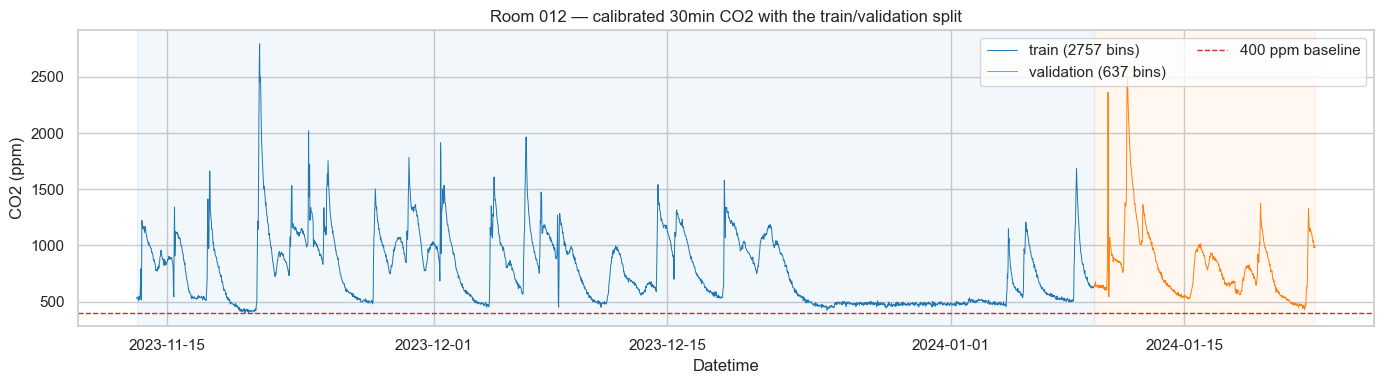

               bins    days      min     mean      max      std
train          2757    57.4    400.0    776.2   2794.3    305.5
validation      637    13.3    427.7    813.7   2503.7    305.9


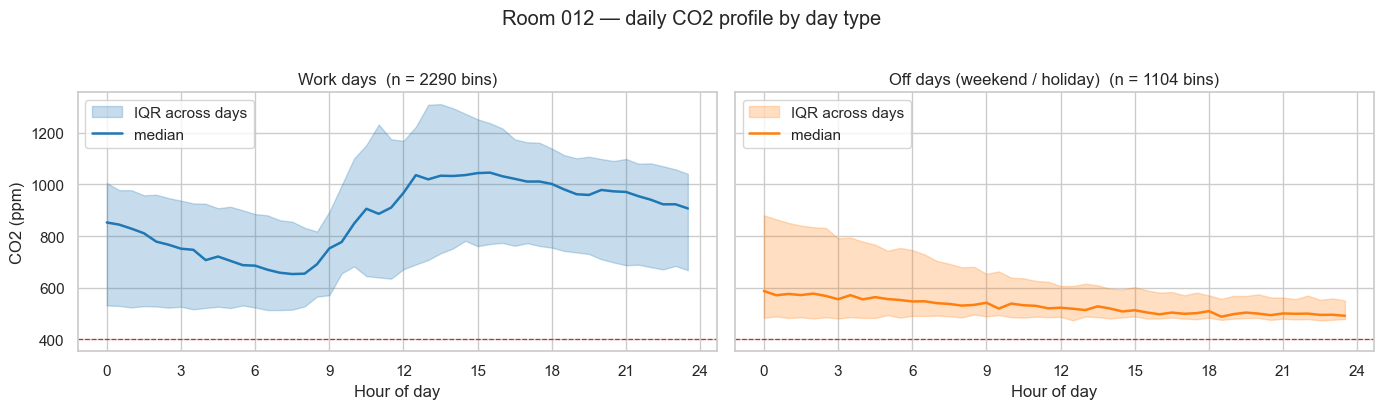

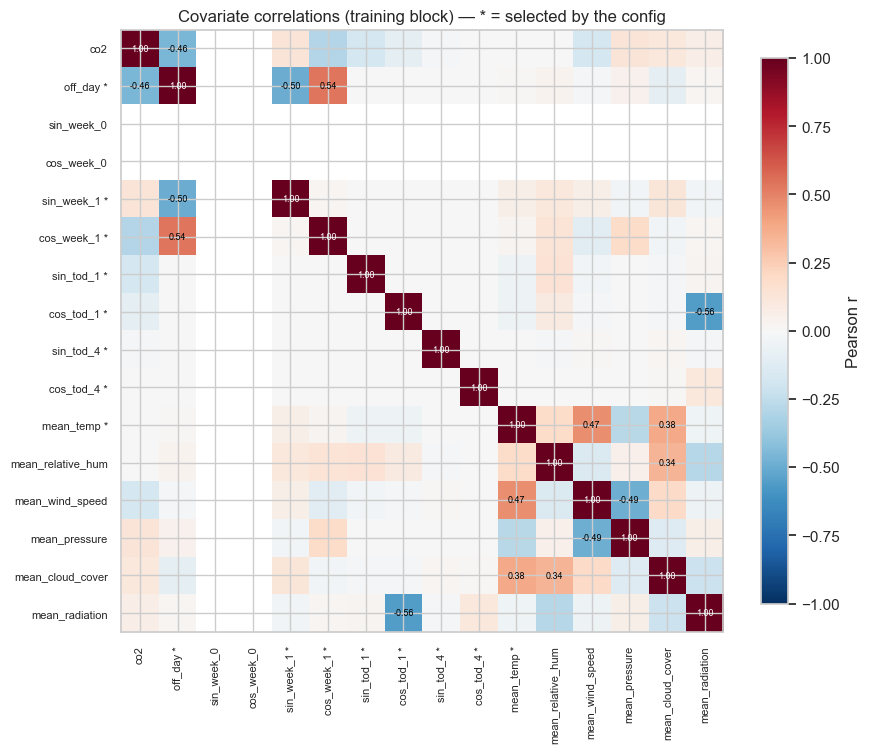

Marginal correlation with CO2 (training block), strongest first:
off_day             -0.457
cos_week_1          -0.293
mean_wind_speed     -0.178
sin_tod_1           -0.172
mean_pressure        0.132
sin_week_1           0.130
mean_cloud_cover     0.104
cos_tod_1           -0.099
mean_radiation       0.063
sin_tod_4           -0.013
cos_tod_4            0.008
mean_relative_hum   -0.004
mean_temp           -0.000
sin_week_0             NaN
cos_week_0             NaN
Name: co2, dtype: float64


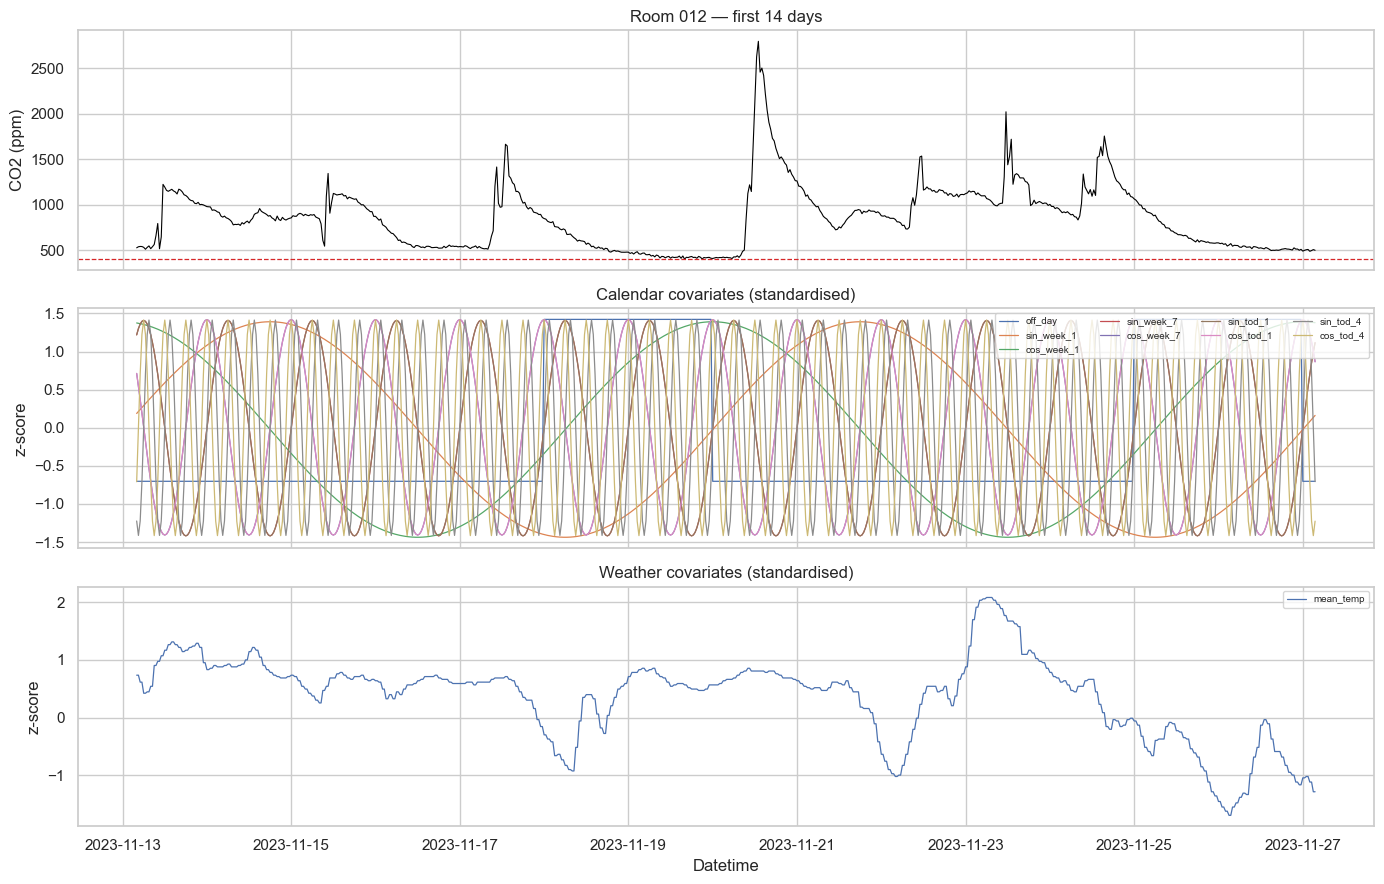

In [13]:
WINDOW_DAYS = 14
ys_np       = np.asarray(ys)

# --- 1. the series and the split boundary ------------------------------------------
blocks = [("train", 0, TRAIN_IDX, "tab:blue"),
          ("validation", TRAIN_IDX, len(ys), "tab:orange")]

fig, ax = plt.subplots(figsize=(14, 4))
for label, lo, hi, colour in blocks:
    ax.plot(dates[lo:hi], ys_np[lo:hi], lw=0.7, color=colour, label=f"{label} ({hi - lo} bins)")
    ax.axvspan(dates[lo], dates[hi - 1], color=colour, alpha=0.06)
ax.axhline(BASELINE_PPM, color="tab:red", ls="--", lw=1.0, label=f"{BASELINE_PPM:.0f} ppm baseline")
ax.set(title=f"{room_name} — calibrated {BIN} CO2 with the train/validation split",
       ylabel="CO2 (ppm)", xlabel="Datetime")
ax.legend(loc="upper right", ncol=2)
plt.tight_layout(); plt.show()

print(f"{'':<12}{'bins':>7}{'days':>8}{'min':>9}{'mean':>9}{'max':>9}{'std':>9}")
for label, lo, hi, _ in blocks:
    blk = ys_np[lo:hi]
    print(f"{label:<12}{hi - lo:>7}{(hi - lo) * BIN_SECONDS / 86400:>8.1f}"
          f"{blk.min():>9.1f}{blk.mean():>9.1f}{blk.max():>9.1f}{blk.std():>9.1f}")

# --- 2. daily profile, work days vs off days ---------------------------------------
# Read straight off the timestamps so this view is independent of USE_OFF_DAY.
from drivers.utils import is_holiday_mask
off_day = np.asarray(dates.dayofweek >= 5) | is_holiday_mask(dates)
hour    = np.asarray(dates.hour + dates.minute / 60.0)

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for ax, (label, mask, colour) in zip(axes, [("Work days", ~off_day, "tab:blue"),
                                            ("Off days (weekend / holiday)", off_day, "tab:orange")]):
    q = (pd.DataFrame({"hour": hour[mask], "co2": ys_np[mask]})
         .groupby("hour")["co2"].quantile([0.25, 0.5, 0.75]).unstack())
    ax.fill_between(q.index, q[0.25], q[0.75], color=colour, alpha=0.25, label="IQR across days")
    ax.plot(q.index, q[0.5], color=colour, lw=1.8, label="median")
    ax.axhline(BASELINE_PPM, color="tab:red", ls="--", lw=0.9)
    ax.set(title=f"{label}  (n = {mask.sum()} bins)", xlabel="Hour of day")
    ax.set_xticks(range(0, 25, 3)); ax.legend(loc="upper left")
axes[0].set_ylabel("CO2 (ppm)")
fig.suptitle(f"{room_name} — daily CO2 profile by day type", y=1.02)
plt.tight_layout(); plt.show()


# --- 3. correlations over every *available* covariate ------------------------------
X_all, cols_all = build_covariates(dates, tuple((1, 4)), tuple((0, 1)),
                                   use_off_day=True, weather_cols=WEATHER_COLS)
expl = pd.DataFrame(X_all[:TRAIN_IDX], columns=cols_all)
expl.insert(0, "co2", np.asarray(ys_train))
corr   = expl.corr()
labels = [c if c == "co2" or c not in covariate_cols else f"{c} *" for c in corr.columns]

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)), labels, rotation=90, fontsize=8)
ax.set_yticks(range(len(corr)), labels, fontsize=8)
for i in range(len(corr)):
    for j in range(len(corr)):
        v = corr.values[i, j]
        if abs(v) >= 0.3:
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=6.5,
                    color="white" if abs(v) > 0.6 else "black")
fig.colorbar(im, ax=ax, shrink=0.8, label="Pearson r")
ax.set_title("Covariate correlations (training block) — * = selected by the config")
plt.tight_layout(); plt.show()

marg = corr["co2"].drop("co2")
print("Marginal correlation with CO2 (training block), strongest first:")
print(marg.reindex(marg.abs().sort_values(ascending=False).index).round(3))

# --- 4. traces of the selected covariates -----------------------------------------
if num_covariates:
    w        = slice(0, int(WINDOW_DAYS * 86400 / BIN_SECONDS))
    calendar = [c for c in covariate_cols if c.startswith(("off_day", "sin_", "cos_"))]
    panels   = [(t, c) for t, c in [("Calendar covariates (standardised)", calendar),
                                    ("Weather covariates (standardised)",
                                     [c for c in covariate_cols if c not in calendar])] if c]

    fig, axes = plt.subplots(1 + len(panels), 1, figsize=(14, 3 + 3 * len(panels)), sharex=True)
    axes = np.atleast_1d(axes)
    axes[0].plot(dates[w], ys_np[w], lw=0.8, color="black")
    axes[0].axhline(BASELINE_PPM, color="tab:red", ls="--", lw=0.9)
    axes[0].set(ylabel="CO2 (ppm)", title=f"{room_name} — first {WINDOW_DAYS} days")
    for ax, (title, cols) in zip(axes[1:], panels):
        for c in cols:
            ax.plot(dates[w], np.asarray(X_std[w, covariate_cols.index(c)]), lw=0.9, label=c)
        ax.set(ylabel="z-score", title=title)
        ax.legend(loc="upper right", ncol=4, fontsize=7)
    axes[-1].set_xlabel("Datetime")
    plt.tight_layout(); plt.show()

## Fit the three models

A warm-start chain, because the later fits do not converge from a cold start: the Gaussian fit
seeds the autoregressive one, which in turn is lifted to the second-order transition. The lift
is checked before it is fitted — at the seed the second-order model *is* the fitted AR model, so
their log-likelihoods must agree.

All three fits use the same tolerance and the same frozen parameter, so the AIC / BIC comparison
below is between models fitted under identical constraints.

In [14]:
FIT_TOL = 1e-2
FROZEN  = None #{"mu0": False}     # freeze the lowest state mean to avoid a degenerate state
FIT_KW  = dict(ys=ys_train, ts=None, xs=X_train_std, tol=FIT_TOL, frozen=FROZEN)

mu_seed    = jnp.quantile(ys_train, jnp.linspace(0.05, 0.95, STATES)).at[0].set(450)
sigma_seed = jnp.std(ys_train) * jnp.ones(STATES)
tm_seed    = jnp.full((STATES, STATES), 0.1).at[jnp.diag_indices(STATES)].set(0.7)
beta_init  = jnp.zeros((num_covariates, STATES, STATES - 1))

# --- 1. Gaussian emission + covariate transition -----------------------------------
print("=== Gaussian HMM + covariates ===")
gauss_cov = HMM(
    emission=GaussEmission.from_params(mu_seed, sigma_seed),
    transition=DynamicTransition(transition_matrix_to_logits(tm_seed), beta_init),
    inital_distribution=init_dist,
)
gauss_cov.fit(**FIT_KW)
print(f"  log-likelihood: {gauss_cov.log_likelihood():.4f}   converged: {gauss_cov.hmm_results.convergence}")

# --- 2. Autoregressive emission, warm-started from the Gaussian fit -----------------
print("=== Autoregressive HMM + covariates ===")
ar_cov = HMM(
    emission=AutoregressiveGaussEmission.from_params(
        state_means(gauss_cov.emission, ys_train),
        jnp.exp(gauss_cov.emission.log_sigma),
        jnp.zeros((AR_LAGS, STATES)),
    ),
    transition=DynamicTransition(gauss_cov.transition.transition_logits, gauss_cov.transition.beta),
    inital_distribution=init_dist,
)
ar_cov.fit(**FIT_KW)
print(f"  log-likelihood: {ar_cov.log_likelihood():.4f}   converged: {ar_cov.hmm_results.convergence}")
print(f"  phi (per state): {np.asarray(ar_cov.emission.phi())}")

# --- 3. Second-order transition, lifted from the AR fit ----------------------------
print(f"=== Second-order (order {ORDER}) HMM + covariates ===")
AUG_STATES = STATES ** ORDER
# Augmented state i encodes (s_{t-1}, s_t) as i = s_{t-1} * STATES + s_t, so the current base
# state is i % STATES. `mu_vals` tiles the STATES base means up to len(log_sigma), so sigma and
# phi must be *tiled* (not repeated) to stay aligned with that convention.
so_cov = HMM(
    emission=AutoregressiveGaussEmission.from_params(
        state_means(ar_cov.emission, ys_train)[:STATES],
        jnp.tile(jnp.exp(ar_cov.emission.log_sigma), STATES),
        jnp.tile(ar_cov.emission.phi(), (1, STATES)),
    ),
    transition=DynamicTransitionHigherOrder.from_first_order(ar_cov.transition, order=ORDER),
    # No stationary distribution for a covariate-driven chain — uniform over the augmented
    # states, whose base-state marginal is the uniform used by the other two models.
    inital_distribution=jnp.full(AUG_STATES, 1.0 / AUG_STATES),
)
ll_seed = so_cov.log_likelihood(ys=ys_train, xs=X_train_std)
ll_ar   = ar_cov.log_likelihood(ys=ys_train, xs=X_train_std)
print(f"  seed LL {ll_seed:.4f} vs AR+cov LL {ll_ar:.4f}  (difference {ll_seed - ll_ar:.2e})")
so_cov.fit(**FIT_KW)
print(f"  log-likelihood: {so_cov.log_likelihood():.4f}   converged: {so_cov.hmm_results.convergence}")

models = {"Gaussian + cov": gauss_cov, "Autoregressive + cov": ar_cov, "Second-order + cov": so_cov}

=== Gaussian HMM + covariates ===
  log-likelihood: -15615.2030   converged: True
=== Autoregressive HMM + covariates ===
  log-likelihood: -12017.1303   converged: True
  phi (per state): [[0.93157527 0.96855948 0.92716956 0.79948556]]
=== Second-order (order 2) HMM + covariates ===
  seed LL -12017.1303 vs AR+cov LL -12017.1303  (difference 0.00e+00)
  log-likelihood: -11970.1313   converged: True


## In-sample fit

State parameters, then the likelihood criteria. Only the means stay tied to the `STATES` base
states — the second-order fit gets one sigma per *augmented* state, and an almost-never-visited
state lets its sigma run toward 0 (the usual unbounded-likelihood spike), so occupancy and sigma
are shown side by side rather than buried in the log-likelihood.

In [15]:
for name, m in models.items():
    mu = np.asarray(state_means(m.emission, ys_train))
    sd = np.asarray(jnp.exp(m.emission.log_sigma))
    print(name)
    print(f"  state means : {np.round(mu[:STATES], 1)}")
    if sd.size == STATES:
        print(f"  state sigmas: {np.round(sd, 1)}")
    else:
        utt = np.asarray(m.state_results.utt).reshape(len(ys_train), -1)
        print("  mean filtered occupancy (rows = s_t-1, cols = s_t):")
        print(np.round(utt.mean(axis=0).reshape(-1, STATES), 4))
        print("  state sigmas (same layout):")
        print(np.round(sd.reshape(-1, STATES), 2))

fit_table = pd.DataFrame([
    {"Model": name,
     "LL": m.hmm_results.log_likelihood,
     "#Params": m.hmm_results.num_params,
     "AIC": AIC(m.hmm_results),
     "BIC": BIC(m.hmm_results, len(ys_train)),
     "Converged": m.hmm_results.convergence}
    for name, m in models.items()
])
fit_table["dAIC"] = fit_table["AIC"] - fit_table["AIC"].min()
fit_table["dBIC"] = fit_table["BIC"] - fit_table["BIC"].min()
fit_table = fit_table[["Model", "LL", "#Params", "AIC", "dAIC", "BIC", "dBIC", "Converged"]]

write_latex_table(fit_table.round(2), TABLE_DIR / "fit_criteria.tex",
                  caption=f"In-sample fit criteria, {room_name} ({BIN}).",
                  label="tab:week5-fit-criteria")
fit_table.round(2)

Gaussian + cov
  state means : [ 481.6  607.   904.4 1237.5]
  state sigmas: [ 23.5  60.8  89.8 229.7]
Autoregressive + cov
  state means : [ 487.7  531.4 1036.  1536.2]
  state sigmas: [ 12.6  15.5  21.6 211.4]
Second-order + cov
  state means : [ 487.8  530.9 1065.3 1555. ]
  mean filtered occupancy (rows = s_t-1, cols = s_t):
[[0.3931 0.0078 0.     0.0004]
 [0.0065 0.3473 0.0118 0.0008]
 [0.     0.0124 0.1478 0.0074]
 [0.002  0.     0.0076 0.0553]]
  state sigmas (same layout):
[[1.2600e+01 1.3020e+01 2.6080e+01 2.0000e-02]
 [9.9600e+00 1.5840e+01 2.3170e+01 2.3440e+02]
 [1.2560e+01 7.2000e+00 2.1960e+01 1.2184e+02]
 [1.4380e+01 1.5480e+01 2.2910e+01 2.2264e+02]]


,Model,LL,#Params,AIC,dAIC,BIC,dBIC,Converged
0,Gaussian + cov,-15615.20,140,31510.41,7188.15,32339.47,7164.46,True
1,Autoregressive + cov,-12017.13,144,24322.26,0.00,25175.01,0.00,True
2,Second-order + cov,-11970.13,204,24348.26,26.00,25556.33,381.32,True


## Residual and state diagnostics

Pseudo-residual diagnostics per model, then the decoded (most likely filtered) state over the
training block.

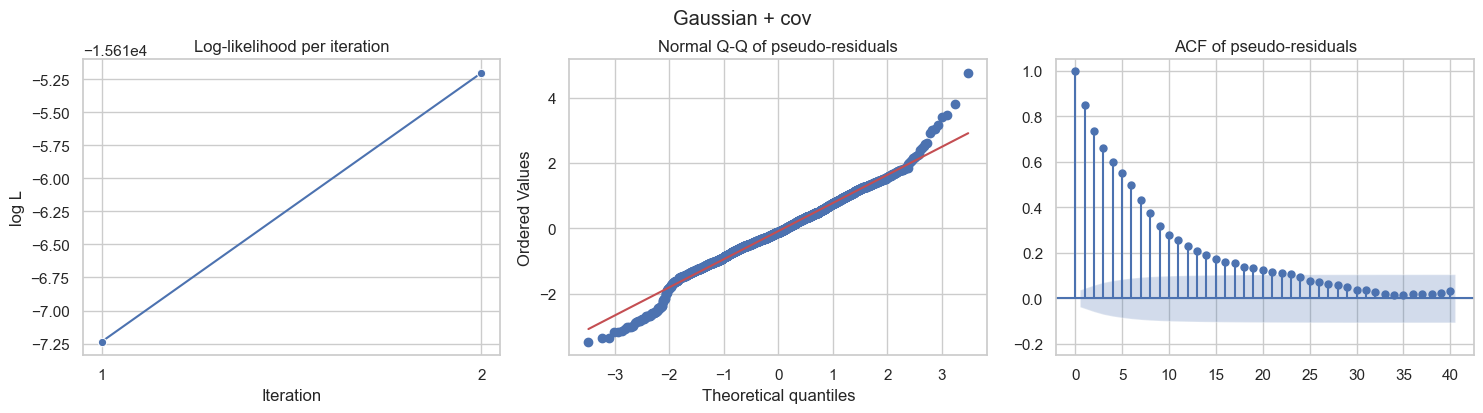

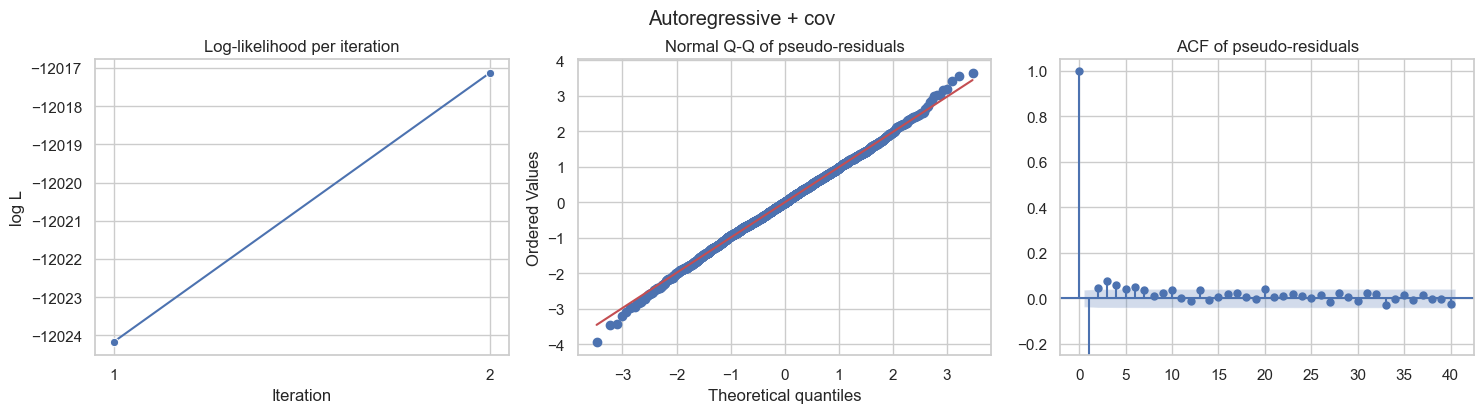

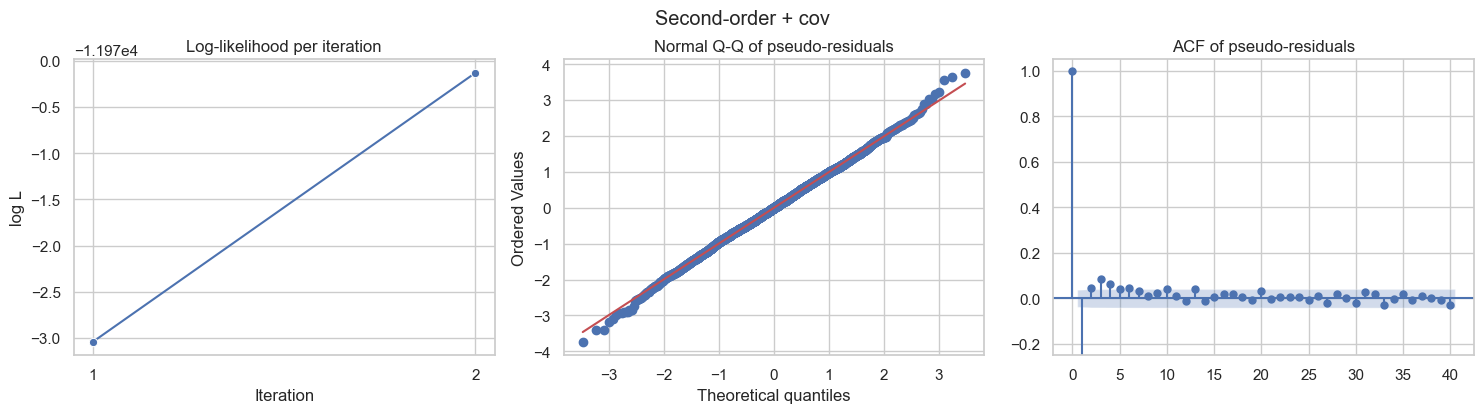

In [16]:
for name, m in models.items():
    fig = plot_hmm_diagnostics(m)
    fig.suptitle(name, y=1.03)
    plt.show()

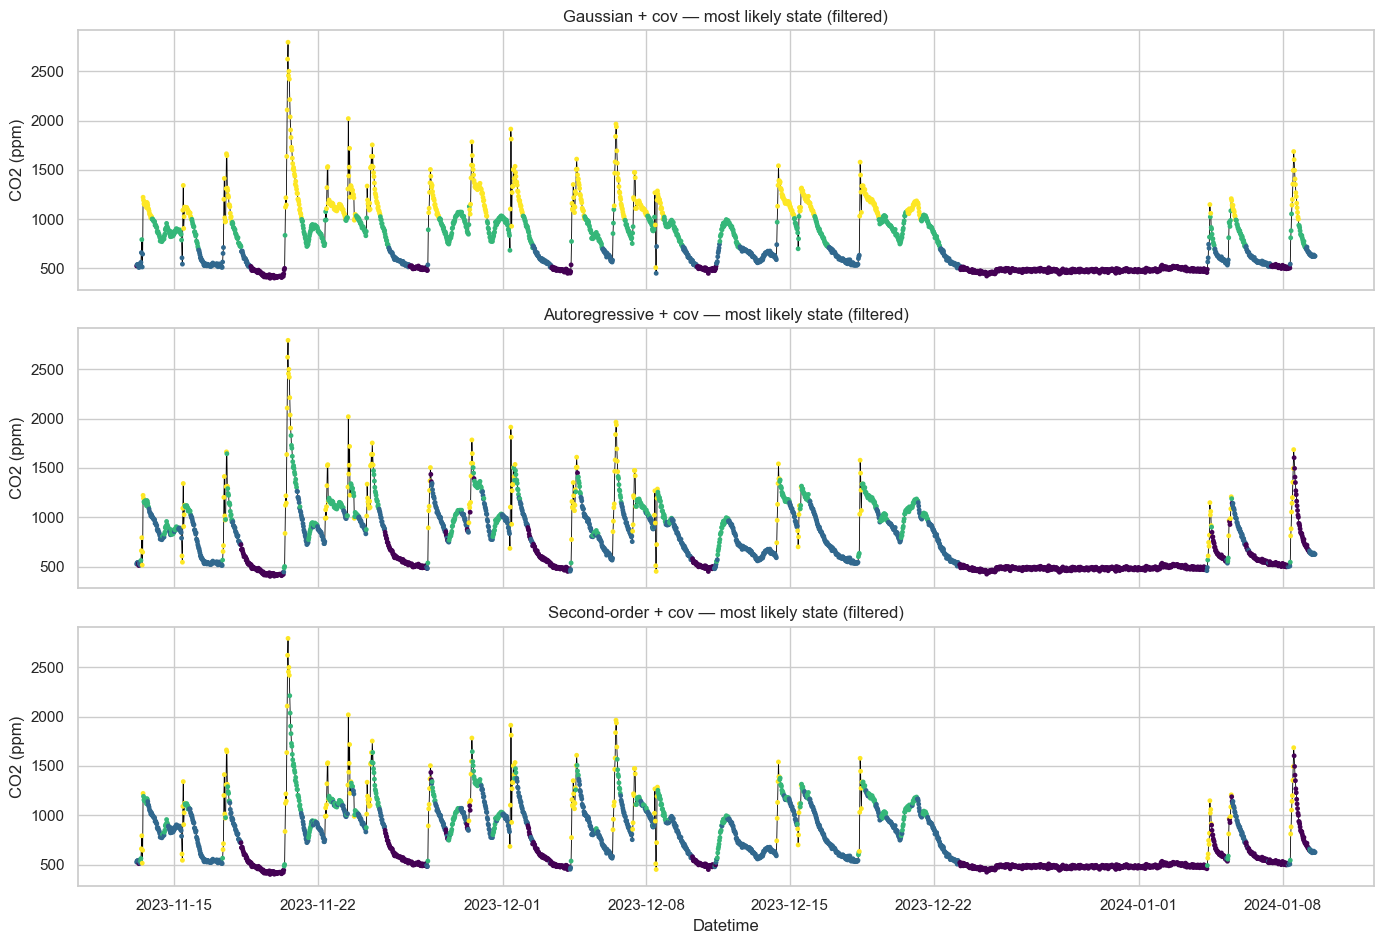

In [17]:
fig, axes = plt.subplots(len(models), 1, figsize=(14, 3.2 * len(models)), sharex=True)
for ax, (name, m) in zip(np.atleast_1d(axes), models.items()):
    utt = np.asarray(m.state_results.utt).reshape(len(ys_train), -1)
    # Augmented index i has current base state i % STATES, so the second-order model
    # shares one colour scale with the first-order ones.
    decoded = utt.argmax(axis=1) % STATES
    ax.plot(dates[:TRAIN_IDX], np.asarray(ys_train), color="black", lw=0.6, zorder=1)
    ax.scatter(dates[:TRAIN_IDX], np.asarray(ys_train), c=decoded, cmap="viridis", s=6, zorder=2)
    ax.set(title=f"{name} — most likely state (filtered)", ylabel="CO2 (ppm)")
np.atleast_1d(axes)[-1].set_xlabel("Datetime")
plt.tight_layout(); plt.show()

## Rolling forecasts on the validation block

A fixed `HORIZON_HOURS`-ahead forecast anchored at *every* validation observation, against a
persistence baseline. The filtered state distribution at the anchor is propagated forward
through the covariate-driven transition matrices, and the emission mean is taken under the
resulting state distribution; for the autoregressive models each prediction is fed back in as
the next step's lag. Anchors stop `K` steps before the end of the block so every target lies
inside validation and nothing is scored against the training block.

In [18]:
K = int(round(HORIZON_HOURS * 3600 / BIN_SECONDS))
print(f"Horizon: {HORIZON_HOURS} h = {K} steps")

start, end = TRAIN_IDX, len(ys)
forecasts = {"Persistence baseline": rolling_persistence(ys, start, end, K)}
for name, m in models.items():
    forecasts[name] = rolling_forecast(m, ys, X_std, start, end, K)

pred_table = pd.DataFrame([
    {"Model": name, "RMSE": rmse(yt, yp), "MAPE%": mape(yt, yp), "R2": r2_score(yt, yp), "n": len(yt)}
    for name, (idx, yt, yp) in forecasts.items()
]).sort_values("RMSE").reset_index(drop=True)

write_latex_table(pred_table.round(3), TABLE_DIR / "validation_forecast.tex",
                  caption=f"Rolling {HORIZON_HOURS}-hour-ahead validation forecast accuracy, "
                          f"{room_name} ({BIN}).",
                  label="tab:week5-validation-forecast")
pred_table.round(3)

Horizon: 6 h = 12 steps


,Model,RMSE,MAPE%,R2,n
0,Second-order + cov,199.540,11.538,0.580,625
1,Autoregressive + cov,205.712,12.144,0.554,625
2,Gaussian + cov,215.907,13.391,0.508,625
3,Persistence baseline,261.890,14.322,0.277,625


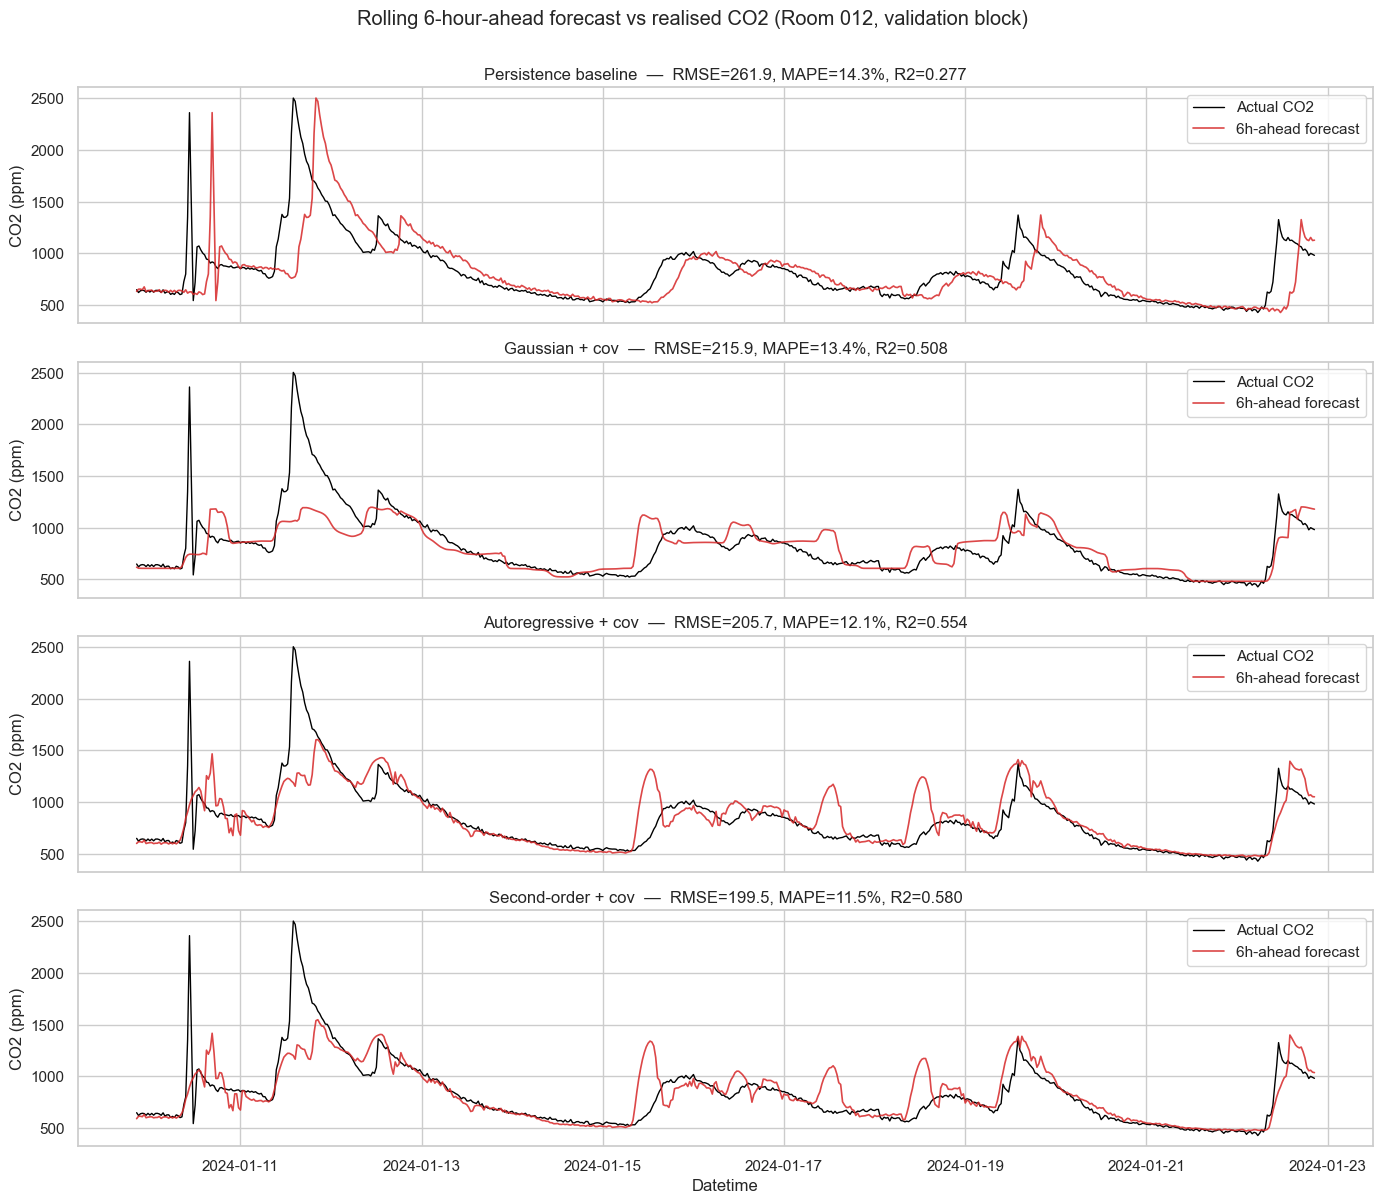

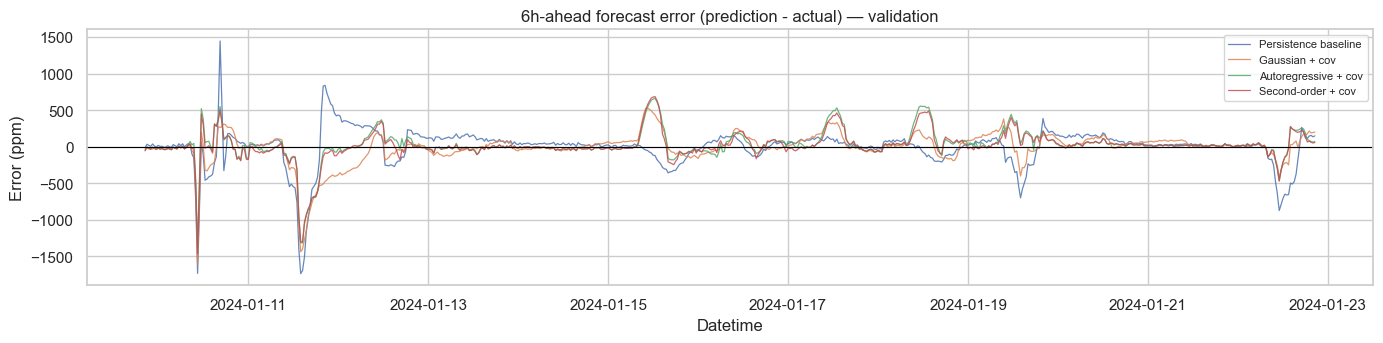

In [19]:
# --- forecast vs realised, one panel per model -------------------------------------
fig, axes = plt.subplots(len(forecasts), 1, figsize=(14, 3 * len(forecasts)), sharex=True)
for ax, (name, (idx, yt, yp)) in zip(np.atleast_1d(axes), forecasts.items()):
    ax.plot(dates[idx], yt, color="black", lw=1.0, label="Actual CO2")
    ax.plot(dates[idx], yp, color="tab:red", lw=1.2, alpha=0.85,
            label=f"{HORIZON_HOURS}h-ahead forecast")
    ax.set(title=f"{name}  —  RMSE={rmse(yt, yp):.1f}, MAPE={mape(yt, yp):.1f}%, "
                 f"R2={r2_score(yt, yp):.3f}", ylabel="CO2 (ppm)")
    ax.legend(loc="upper right")
np.atleast_1d(axes)[-1].set_xlabel("Datetime")
fig.suptitle(f"Rolling {HORIZON_HOURS}-hour-ahead forecast vs realised CO2 "
             f"({room_name}, validation block)", y=1.002)
plt.tight_layout(); plt.show()

# --- forecast error, all models on one axis ----------------------------------------
fig, ax = plt.subplots(figsize=(14, 3.6))
for name, (idx, yt, yp) in forecasts.items():
    ax.plot(dates[idx], yp - yt, lw=0.9, alpha=0.85, label=name)
ax.axhline(0.0, color="black", lw=0.8)
ax.set(title=f"{HORIZON_HOURS}h-ahead forecast error (prediction - actual) — validation",
       ylabel="Error (ppm)", xlabel="Datetime")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout(); plt.show()

## A single week of the validation block, up close

The block-wide plots above compress two weeks into one axis, which hides the shape of a day.
This is the **first full week** of validation — anchored at the first midnight after the split
so the seven days are calendar-aligned — in three panels: the observed series with off days
shaded, the **autoregressive + covariate** model's most likely state coloured onto that same
line, and the rolling forecasts over the same window.

The state panel is the *filtered* decoding: state `t` is conditioned on observations up to and
including bin `t`, so it shows which regime the model reads the room as being in, not what it
would have guessed blind. The forecast panel below it is the genuinely out-of-sample view.

Room 012 — validation week 2024-01-10 to 2024-01-17 (336 bins, 522-2504 ppm)


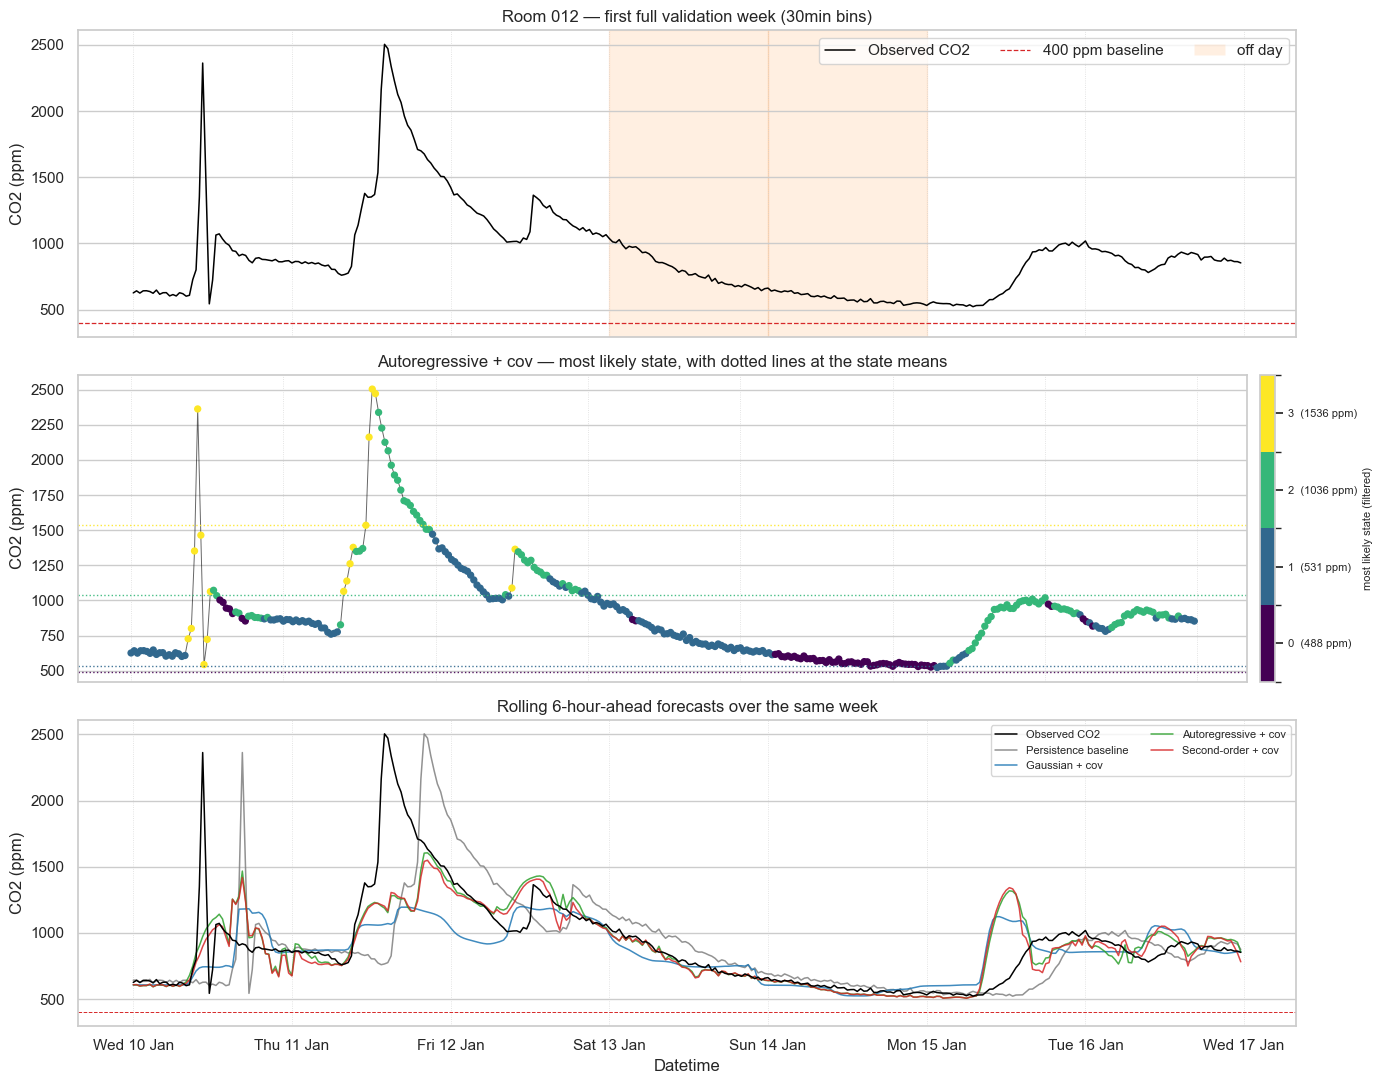

state occupancy over this week (AR + cov):
  state 0 (mu =   487.7 ppm):  19.3% of bins
  state 1 (mu =   531.4 ppm):  45.2% of bins
  state 2 (mu =  1036.0 ppm):  30.1% of bins
  state 3 (mu =  1536.2 ppm):   5.4% of bins


In [20]:
import matplotlib.dates as mdates
from matplotlib.colors import BoundaryNorm
from matplotlib.patches import Patch
from src.api.v4 import ForwardAlgorithm

# --- pick the window: the first whole calendar week inside validation --------------
val_start = dates[TRAIN_IDX]
week_from = val_start.ceil("D")                      # first midnight at or after the split
week_to   = week_from + pd.Timedelta(days=7)
if week_to > dates[-1]:                              # short block: take what validation has
    week_from, week_to = val_start, min(val_start + pd.Timedelta(days=7), dates[-1])
    print(f"validation is shorter than a full aligned week — plotting {week_from} -> {week_to}")

in_week = (dates >= week_from) & (dates < week_to)
w_dates = dates[in_week]
w_ys    = np.asarray(ys)[in_week]
print(f"{room_name} — validation week {week_from:%Y-%m-%d} to {week_to:%Y-%m-%d} "
      f"({in_week.sum()} bins, {w_ys.min():.0f}-{w_ys.max():.0f} ppm)")

# --- decoded states for the AR + cov model over this week --------------------------
# `ar_cov.state_results.utt` only covers the *training* rows it was fitted on, so run the
# forward pass over the whole series to reach validation. This is the **filtered** state --
# conditioned on observations up to and including each bin, not a forecast -- so it says
# which regime the model reads the room as being in, not what it would have predicted blind.
_out     = ForwardAlgorithm().run(ar_cov.params, ar_cov.u_pre, ys=ys, ts=None, xs=X_std)
utt_full = np.asarray(_out.utt).reshape(len(ys), -1)
decoded  = utt_full.argmax(axis=1) % STATES          # % STATES is a no-op at first order
ar_mu    = np.asarray(state_means(ar_cov.emission, ys_train))[:STATES]

fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)

# --- panel 1: the observed series, with off days shaded ----------------------------
ax = axes[0]
ax.plot(w_dates, w_ys, color="black", lw=1.1, label="Observed CO2")
ax.axhline(BASELINE_PPM, color="tab:red", ls="--", lw=0.9, label=f"{BASELINE_PPM:.0f} ppm baseline")

# Shade whole off days (weekend / Danish public holiday) by day, not by bin, so the
# span edges land on midnight rather than on the first and last bin of the day.
day, any_off = week_from, False
while day < week_to:
    if day.dayofweek >= 5 or is_holiday_mask(pd.DatetimeIndex([day]))[0]:
        ax.axvspan(day, day + pd.Timedelta(days=1), color="tab:orange", alpha=0.12, zorder=0)
        any_off = True
    day += pd.Timedelta(days=1)

ax.set(title=f"{room_name} — first full validation week ({BIN} bins)", ylabel="CO2 (ppm)")
handles, labels = ax.get_legend_handles_labels()
if any_off:   # a Patch proxy, so the swatch needs no zero-width span on the axis
    handles.append(Patch(facecolor="tab:orange", alpha=0.12, label="off day"))
ax.legend(handles=handles, loc="upper right", ncol=3)

# --- panel 2: decoded state of the AR + cov model on top of the CO2 line -----------
ax = axes[1]
cmap = plt.get_cmap("viridis", STATES)
norm = BoundaryNorm(np.arange(STATES + 1) - 0.5, STATES)
ax.plot(w_dates, w_ys, color="black", lw=0.7, alpha=0.6, zorder=1)
sc = ax.scatter(w_dates, w_ys, c=decoded[in_week], cmap=cmap, norm=norm, s=18, zorder=2)
# Horizontal guides at the fitted state means, so a state's colour ties to a CO2 level.
for s, mu_s in enumerate(ar_mu):
    ax.axhline(mu_s, color=cmap(s), ls=":", lw=1.0, alpha=0.9)
cbar = fig.colorbar(sc, ax=ax, ticks=range(STATES), pad=0.01, fraction=0.03)
cbar.ax.set_yticklabels([f"{s}  ({mu:.0f} ppm)" for s, mu in enumerate(ar_mu)], fontsize=8)
cbar.set_label("most likely state (filtered)", fontsize=8)
ax.set(title="Autoregressive + cov — most likely state, with dotted lines at the state means",
       ylabel="CO2 (ppm)")

# --- panel 3: the same week with the rolling forecasts -----------------------------
ax = axes[2]
ax.plot(w_dates, w_ys, color="black", lw=1.1, label="Observed CO2", zorder=3)
for (name, (idx, yt, yp)), colour in zip(forecasts.items(),
                                         ["tab:grey", "tab:blue", "tab:green", "tab:red"]):
    sel = (idx >= np.flatnonzero(in_week)[0]) & (idx <= np.flatnonzero(in_week)[-1])
    if sel.any():
        ax.plot(dates[idx[sel]], yp[sel], color=colour, lw=1.1, alpha=0.85, label=name)
ax.axhline(BASELINE_PPM, color="tab:red", ls="--", lw=0.7)
ax.set(title=f"Rolling {HORIZON_HOURS}-hour-ahead forecasts over the same week",
       ylabel="CO2 (ppm)", xlabel="Datetime")
ax.legend(loc="upper right", ncol=2, fontsize=8)

# One tick per day, labelled with the weekday, so the daily cycle is readable.
axes[-1].xaxis.set_major_locator(mdates.DayLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%a %d %b"))
for ax in axes:
    ax.grid(axis="x", ls=":", lw=0.6, alpha=0.7)
plt.tight_layout(); plt.show()

print("state occupancy over this week (AR + cov):")
for s, mu_s in enumerate(ar_mu):
    share = (decoded[in_week] == s).mean()
    print(f"  state {s} (mu = {mu_s:7.1f} ppm): {share:6.1%} of bins")